# Importing necessary Libraries

In [241]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [242]:
# Download necessary NLTK data

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

## Documentation

* TensorFlow Keras Documentation: https://www.tensorflow.org/api_docs/python/tf/keras
* NLTK Documentation: https://www.nltk.org/api/nltk.html

# Load a subset of the dataset:

In [243]:
# Define the path to your dataset
data_path = 'full_dataset.csv'

# Load a subset of the data for initial exploration (e.g., 100,000 rows)
chunk_size = 1000  # Adjust based on system's memory capacity
df = pd.read_csv(data_path, nrows=chunk_size)

In [244]:
# Check dataset shape
print(f'Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n\n')

# Check for missing values
print(df.isnull().sum())

Dataset contains 1000 rows and 7 columns.


Unnamed: 0     0
title          0
ingredients    0
directions     0
link           0
source         0
NER            0
dtype: int64


In [245]:
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [246]:
df.duplicated().sum()

0

# Visualize data distribution:

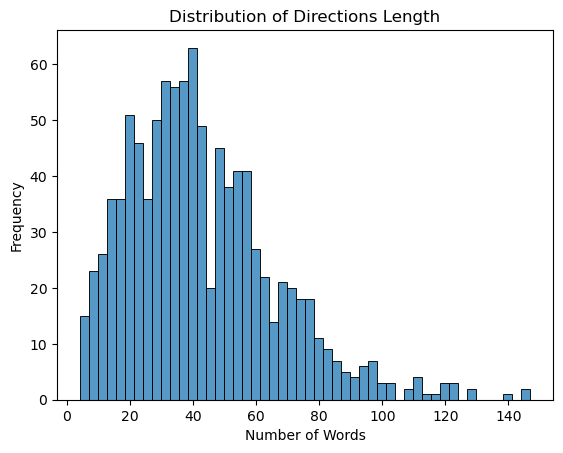

In [247]:
# Length distribution of directions
df['directions_length'] = df['directions'].apply(lambda x: len(str(x).split()))
sns.histplot(df['directions_length'], bins=50)
plt.title('Distribution of Directions Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Standardize text:


In [248]:
# Convert text to lowercase
df['Directions'] = df['directions'].str.lower()
df['Ingredients'] = df['ingredients'].str.lower()

# Remove unnecessary characters and whitespaces:

In [249]:
import re

def clean_text(text):
    text = re.sub(r'\s+', ' ', text)  # Remove extra whitespaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    return text.strip()

df['Directions'] = df['Directions'].apply(clean_text)
df['Ingredients'] = df['Ingredients'].apply(clean_text)

# Text Preprocessing

## Tokenization:

In [250]:
# Initialize tokenizer
tokenizer = Tokenizer()

# Fit tokenizer on Directions
tokenizer.fit_on_texts(df['Directions'])

# Vocabulary size
vocab_size = len(tokenizer.word_index) +1
print(f'Vocabulary Size: {vocab_size}')

Vocabulary Size: 2109


# Remove stopwords (optional):

In [251]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered)

df['Directions'] = df['Directions'].apply(remove_stopwords)

# Stemming/Lemmatization :

In [252]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet',quiet=True)
nltk.download('omw-1.4',quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized)

# Apply lemmatization
df['Directions'] = df['Directions'].apply(lemmatize_text)

# Data Formatting

In [253]:
# Prepare input sequences
input_sequences = []

for line in df['Directions']:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(2, len(token_list)):
        n_gram_sequence = token_list[:i]
        input_sequences.append(n_gram_sequence)

print(f'Total input sequences: {len(input_sequences)}')

Total input sequences: 27391


# Pad sequences and prepare predictors and labels:

In [254]:
# Determine maximum sequence length
max_sequence_len = max([len(seq) for seq in input_sequences])
print(f'Max sequence length: {max_sequence_len}')

# Pad sequences
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# Split into predictors and label
predictors = input_sequences[:, :-1]
labels = input_sequences[:, -1]

# Convert labels to categorical
labels = tf.keras.utils.to_categorical(labels, num_classes=vocab_size)

Max sequence length: 110


# Data Preparation

## Sequence Creation

* We create sequences where each sequence is a progression of words from the Directions. For example:

Directions: "heat oil in a pan add onions cook until golden"

Tokenized: [15, 50, 10, 2, 30, 5, 40, 25, 60, 35, 45]

Sequences:

[15, 50] -> 10

[15, 50, 10] -> 2

...

This prepares the model to predict the next word given a sequence of previous words.

# Train-Test Split

In [255]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(predictors, labels, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Validation samples: {X_val.shape[0]}')

Training samples: 21912
Validation samples: 5479


# Model Building

In [256]:
embedding_dim = 100  

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_len - 1))
model.add(LSTM(150, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dense(vocab_size, activation='softmax'))

# Compile the Model

## Choosing loss function and optimizer:

In [257]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the Model

In [263]:
epochs = 50

history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_val, y_val), batch_size=128)

Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 84s 492ms/step - accuracy: 0.3716 - loss: 2.8763 - val_accuracy: 0.1774 - val_loss: 5.6067
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 77s 446ms/step - accuracy: 0.3753 - loss: 2.8466 - val_accuracy: 0.1790 - val_loss: 5.6237
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 77s 446ms/step - accuracy: 0.3703 - loss: 2.8420 - val_accuracy: 0.1769 - val_loss: 5.6336
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 77s 448ms/step - accuracy: 0.3799 - loss: 2.8199 - val_accuracy: 0.1767 - val_loss: 5.6666
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 78s 454ms/step - accuracy: 0.3830 - loss: 2.7982 - val_accuracy: 0.1780 - val_loss: 5.6871
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 87s 509ms/step - accuracy: 0.3907 - loss: 2.7579 - val_accuracy: 0.1772 - val_loss: 5.6925
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 96s 560ms/step - accuracy: 0.3902 - loss: 2.7549 - val_accuracy: 0.1785 - val_loss: 5.7143
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 78s 456ms/step - accuracy: 0.3931 - loss: 2

# Visualize training history:

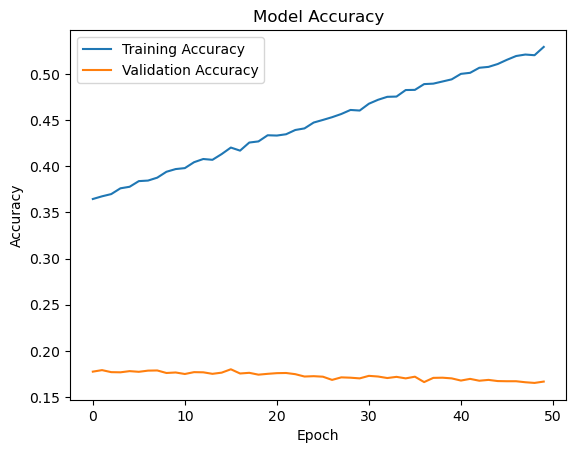

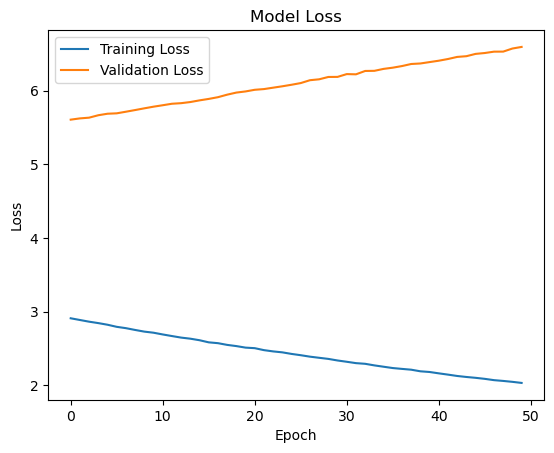

In [264]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation and Recipe Generation

In [265]:
def generate_recipe(seed_text, next_words, max_sequence_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)
        
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [266]:
seed_text = "preheat oven to 350 degrees"
generated_recipe = generate_recipe(seed_text, next_words=100, max_sequence_len=max_sequence_len)
print(generated_recipe)

preheat oven to 350 degrees peel thin bake 400u00b0 oven 20 minute cut half lengthwise leaving 14inch knife cut square yield 4 serving preparation time toothpick 8 8 minute get 300u00b0 several hour wash served seed cutting enjoy careful sieve leftover headspace continually really time 30 time whether serve fat serve fat remove day better mush rinsing skillet brown sugar garlic please right crepe crepe favorite cooked lard dividing moisten garlic water hot golden heat hot sauce soup heat heat 8 8 minute chicken chicken biscuit top biscuit yield 4 4 4 4 serving preparation minute oven couple serving serve fat serve later make 24


In [267]:
print("Generated Recipe:")
print(generated_recipe)

Generated Recipe:
preheat oven to 350 degrees peel thin bake 400u00b0 oven 20 minute cut half lengthwise leaving 14inch knife cut square yield 4 serving preparation time toothpick 8 8 minute get 300u00b0 several hour wash served seed cutting enjoy careful sieve leftover headspace continually really time 30 time whether serve fat serve fat remove day better mush rinsing skillet brown sugar garlic please right crepe crepe favorite cooked lard dividing moisten garlic water hot golden heat hot sauce soup heat heat 8 8 minute chicken chicken biscuit top biscuit yield 4 4 4 4 serving preparation minute oven couple serving serve fat serve later make 24


# Thank You
## Eklavya Yaadav